In [1]:
# Basic Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Models
import statsmodels.api as sm
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree


In [2]:
df = pd.read_csv(r"D:\DSGA\5 Classification Techniques for Predictive Modeling\Project\INNHotelsGroup.csv")
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [3]:
df.shape

(36275, 19)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [5]:
df.isnull().sum()

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

In [6]:
df.drop("Booking_ID", axis=1, inplace=True)

Basic EDA


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.0,1.844962,0.518715,0.0,2.0,2.00,2.0,4.0
no_of_children,36275.0,0.105279,0.402648,0.0,0.0,0.00,0.0,10.0
no_of_weekend_nights,36275.0,0.810724,0.870644,0.0,0.0,1.00,2.0,7.0
no_of_week_nights,36275.0,2.204300,1.410905,0.0,1.0,2.00,3.0,17.0
required_car_parking_space,36275.0,0.030986,0.173281,0.0,0.0,0.00,0.0,1.0
lead_time,36275.0,85.232557,85.930817,0.0,17.0,57.00,126.0,443.0
arrival_year,36275.0,2017.820427,0.383836,2017.0,2018.0,2018.00,2018.0,2018.0
arrival_month,36275.0,7.423653,3.069894,1.0,5.0,8.00,10.0,12.0
arrival_date,36275.0,15.596995,8.740447,1.0,8.0,16.00,23.0,31.0
repeated_guest,36275.0,0.025637,0.158053,0.0,0.0,0.00,0.0,1.0


In [10]:
df["booking_status"].value_counts(normalize=True) * 100

booking_status
Not_Canceled    67.236389
Canceled        32.763611
Name: proportion, dtype: float64

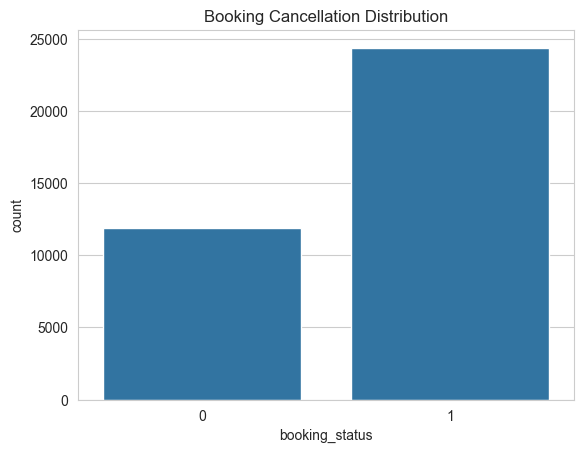

booking_status
1    67.236389
0    32.763611
Name: proportion, dtype: float64

In [30]:
sns.countplot(x="booking_status", data=df)
plt.title("Booking Cancellation Distribution")
plt.show()

df["booking_status"].value_counts(normalize=True) * 100

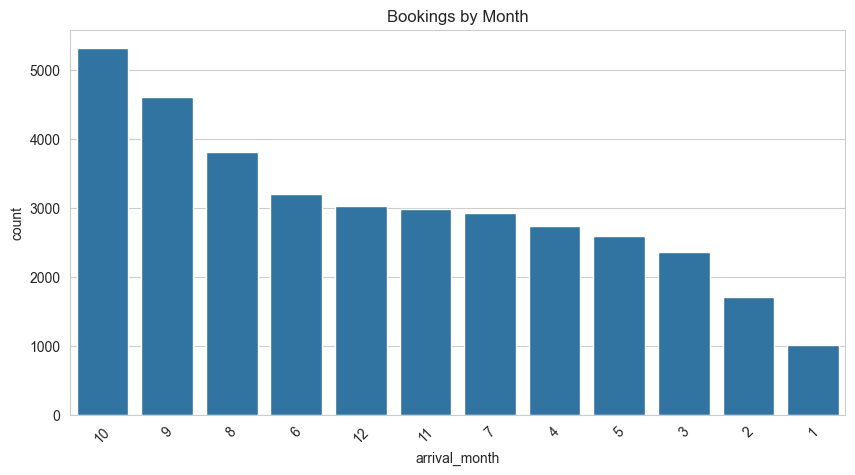

In [31]:
plt.figure(figsize=(10,5))
sns.countplot(x="arrival_month", data=df, order=df["arrival_month"].value_counts().index)
plt.title("Bookings by Month")
plt.xticks(rotation=45)
plt.show()

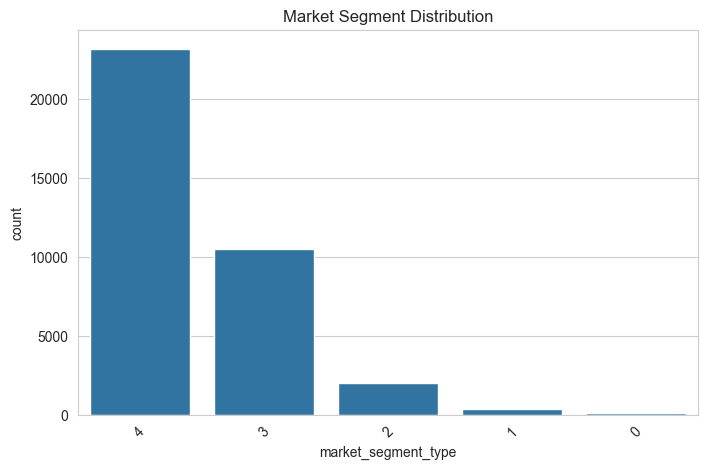

In [32]:
plt.figure(figsize=(8,5))
sns.countplot(x="market_segment_type", data=df,
              order=df["market_segment_type"].value_counts().index)
plt.title("Market Segment Distribution")
plt.xticks(rotation=45)
plt.show()

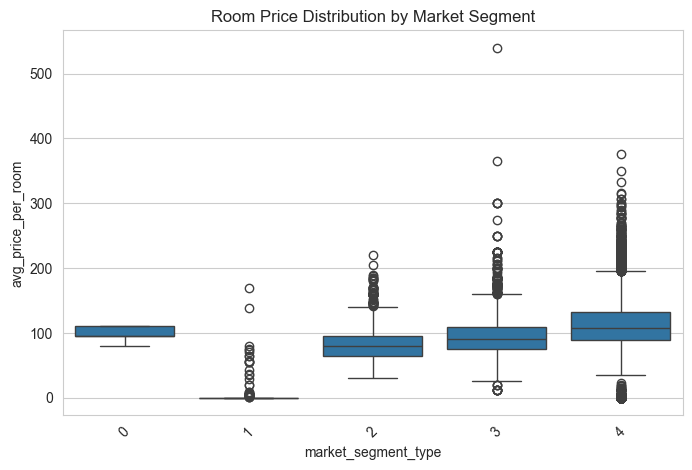

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(x="market_segment_type", y="avg_price_per_room", data=df)
plt.xticks(rotation=45)
plt.title("Room Price Distribution by Market Segment")
plt.show()

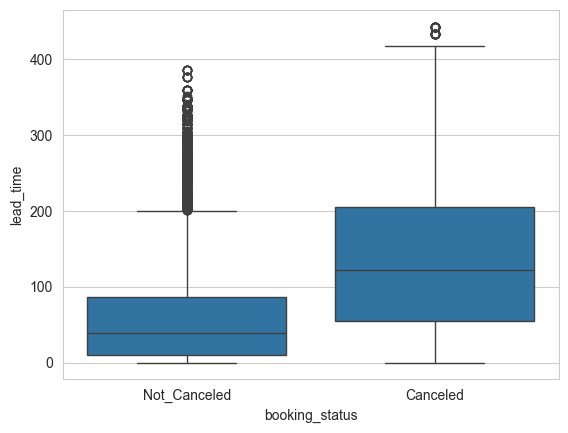

In [11]:
sns.boxplot(x="booking_status", y="lead_time", data=df)
plt.show()

In [13]:
df["market_segment_type"].value_counts()

market_segment_type
Online           23214
Offline          10528
Corporate         2017
Complementary      391
Aviation           125
Name: count, dtype: int64

In [14]:
df.groupby("market_segment_type")["avg_price_per_room"].mean().sort_values()

market_segment_type
Complementary      3.141765
Corporate         82.911740
Offline           91.632679
Aviation         100.704000
Online           112.256855
Name: avg_price_per_room, dtype: float64

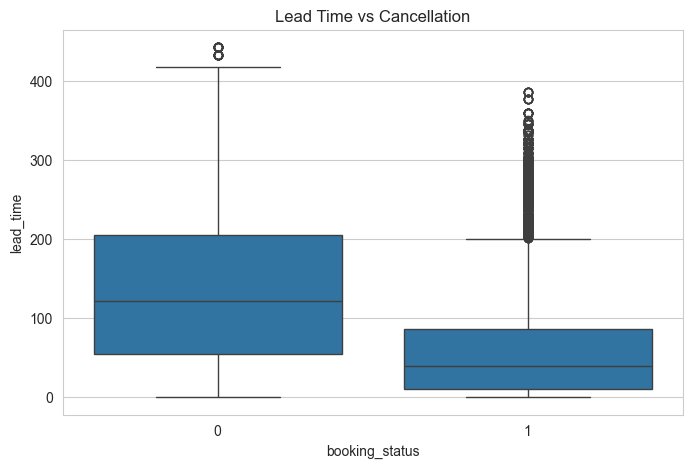

In [34]:
plt.figure(figsize=(8,5))
sns.boxplot(x="booking_status", y="lead_time", data=df)
plt.title("Lead Time vs Cancellation")
plt.show()

In [35]:
pd.crosstab(df["repeated_guest"], df["booking_status"], normalize='index') * 100

booking_status,0,1
repeated_guest,,
0,33.580422,66.419578
1,1.720430,98.279570


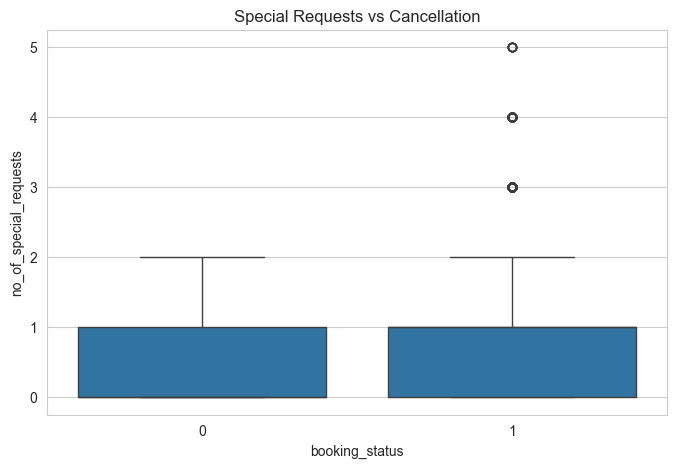

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(x="booking_status", y="no_of_special_requests", data=df)
plt.title("Special Requests vs Cancellation")
plt.show()

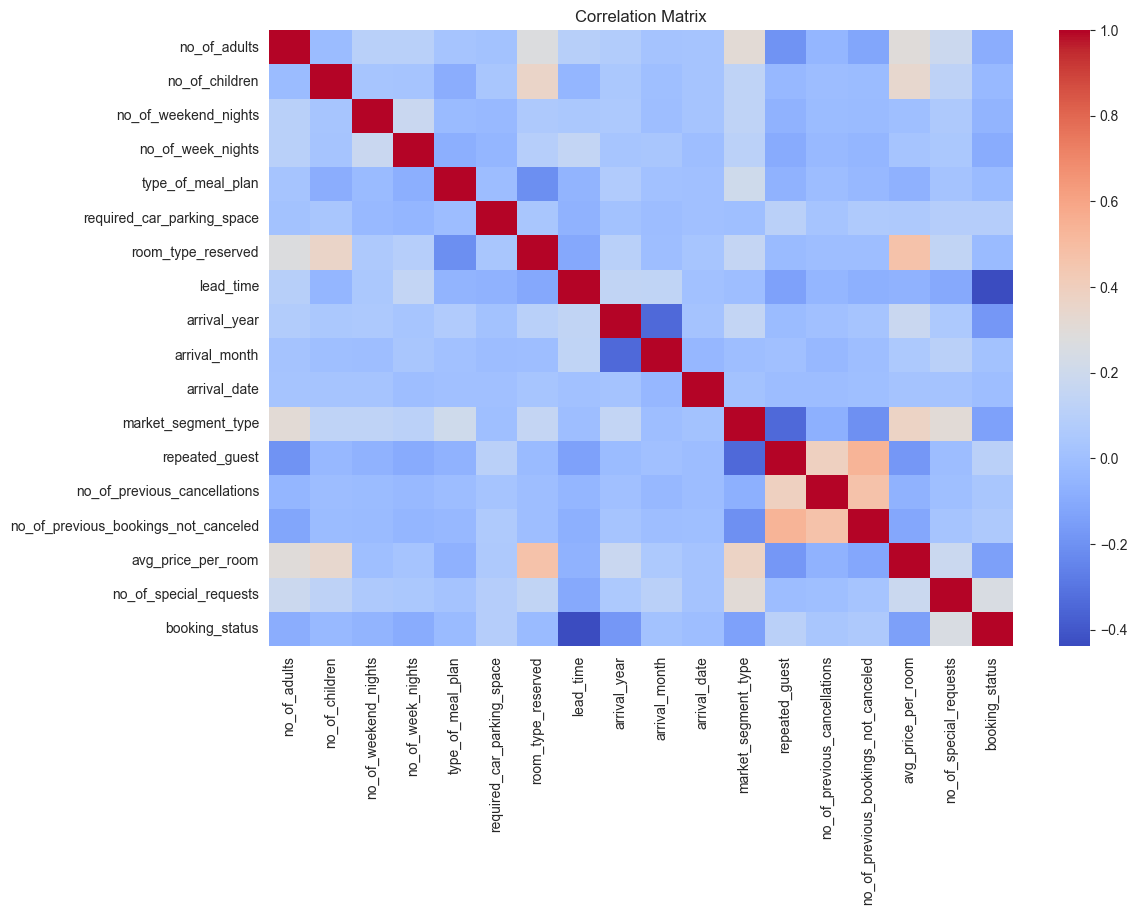

In [37]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

EDA Questions

Busiest Months

In [107]:
df["arrival_month"].value_counts()

arrival_month
10    5317
9     4611
8     3813
6     3203
12    3021
11    2980
7     2920
4     2736
5     2598
3     2358
2     1704
1     1014
Name: count, dtype: int64

In [108]:
df["arrival_month"].value_counts(normalize=True) * 100

arrival_month
10    14.657478
9     12.711234
8     10.511371
6      8.829773
12     8.328050
11     8.215024
7      8.049621
4      7.542385
5      7.161957
3      6.500345
2      4.697450
1      2.795314
Name: proportion, dtype: float64

Market Segment Distribution

In [109]:
df["market_segment_type"].value_counts()

market_segment_type
4    23214
3    10528
2     2017
1      391
0      125
Name: count, dtype: int64

In [110]:
df["market_segment_type"].value_counts(normalize=True) * 100

market_segment_type
4    63.994487
3    29.022743
2     5.560303
1     1.077877
0     0.344590
Name: proportion, dtype: float64

Room Price by Market Segment

In [111]:
df.groupby("market_segment_type")["avg_price_per_room"].mean().sort_values(ascending=False)

market_segment_type
4    112.256855
0    100.704000
3     91.632679
2     82.911740
1      3.141765
Name: avg_price_per_room, dtype: float64

Overall Cancellation Percentage

In [112]:
df["booking_status"].value_counts(normalize=True) * 100

booking_status
1    67.236389
0    32.763611
Name: proportion, dtype: float64

Repeated Guest Cancellation Rate

In [113]:
pd.crosstab(df["repeated_guest"], df["booking_status"], normalize="index") * 100

booking_status,0,1
repeated_guest,,
0,33.580422,66.419578
1,1.720430,98.279570


Special Requests vs Cancellation

In [114]:
pd.crosstab(df["no_of_special_requests"], df["booking_status"], normalize="index") * 100

booking_status,0,1
no_of_special_requests,,
0,43.206755,56.793245
1,23.766816,76.233184
2,14.596700,85.403300
3,0.000000,100.000000
4,0.000000,100.000000
5,0.000000,100.000000


Encode Categorical Variables

In [65]:
X = df.drop("booking_status", axis=1)
y = df["booking_status"]

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [69]:
X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)

In [70]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

def calculate_vif(dataframe):
    vif = pd.DataFrame()
    vif["Feature"] = dataframe.columns
    vif["VIF"] = [
        variance_inflation_factor(dataframe.values, i)
        for i in range(dataframe.shape[1])
    ]
    return vif.sort_values(by="VIF", ascending=False)

calculate_vif(X_train_df)

,Feature,VIF
12,repeated_guest,1.643774
15,avg_price_per_room,1.634910
14,no_of_previous_bookings_not_canceled,1.589147
11,market_segment_type,1.557177
6,room_type_reserved,1.523695
13,no_of_previous_cancellations,1.324972
8,arrival_year,1.297043
0,no_of_adults,1.293447
1,no_of_children,1.250551
9,arrival_month,1.246733


Initial Logistic Regression

In [71]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train_df)

logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.437517
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25374
Method:                           MLE   Df Model:                           17
Date:                Sun, 22 Feb 2026   Pseudo R-squ.:                  0.3083
Time:                        22:24:05   Log-Likelihood:                -11109.
converged:                       True   LL-Null:                       -16060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                    1.1933      0.

In [73]:
X_train_df = X_train_df.drop(columns=["no_of_previous_bookings_not_canceled"])
X_test_df = X_test_df.drop(columns=["no_of_previous_bookings_not_canceled"])

In [75]:
X_train_sm = sm.add_constant(X_train_df)
result = sm.Logit(y_train, X_train_sm).fit()

Optimization terminated successfully.
         Current function value: 0.437518
         Iterations 9


In [76]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25375
Method:                           MLE   Df Model:                           16
Date:                Sun, 22 Feb 2026   Pseudo R-squ.:                  0.3083
Time:                        22:27:40   Log-Likelihood:                -11109.
converged:                       True   LL-Null:                       -16060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            1.1919      0.022     53.907      0.000       1.149       1.235
no_of_adults                     0.0079      0.019      0.418      0.676     

In [77]:
X_train_df = X_train_df.drop(columns=["no_of_adults"])
X_test_df = X_test_df.drop(columns=["no_of_adults"])

In [78]:
X_train_sm = sm.add_constant(X_train_df)
result = sm.Logit(y_train, X_train_sm).fit()

Optimization terminated successfully.
         Current function value: 0.437521
         Iterations 9


In [79]:
X_train_df = X_train_df.drop(columns=["no_of_children"])
X_test_df = X_test_df.drop(columns=["no_of_children"])

In [80]:
X_train_sm = sm.add_constant(X_train_df)
result = sm.Logit(y_train, X_train_sm).fit()

Optimization terminated successfully.
         Current function value: 0.437527
         Iterations 9


In [81]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25377
Method:                           MLE   Df Model:                           14
Date:                Sun, 22 Feb 2026   Pseudo R-squ.:                  0.3082
Time:                        22:29:07   Log-Likelihood:                -11110.
converged:                       True   LL-Null:                       -16060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            1.1923      0.022     53.950      0.000       1.149       1.236
no_of_weekend_nights            -0.1155      0.017     -6.834      0.000     

In [82]:
X_train_df = X_train_df.drop(columns=["no_of_previous_cancellations"])
X_test_df = X_test_df.drop(columns=["no_of_previous_cancellations"])

In [83]:
X_train_sm = sm.add_constant(X_train_df)
result = sm.Logit(y_train, X_train_sm).fit()

Optimization terminated successfully.
         Current function value: 0.437593
         Iterations 8


In [87]:
X_train_df = X_train_df.drop(columns=["arrival_date"])
X_test_df = X_test_df.drop(columns=["arrival_date"])

In [88]:
X_train_sm = sm.add_constant(X_train_df)
result = sm.Logit(y_train, X_train_sm).fit()

Optimization terminated successfully.
         Current function value: 0.440109
         Iterations 9


In [89]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25380
Method:                           MLE   Df Model:                           11
Date:                Sun, 22 Feb 2026   Pseudo R-squ.:                  0.3042
Time:                        22:31:02   Log-Likelihood:                -11175.
converged:                       True   LL-Null:                       -16060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          1.1822      0.021     56.115      0.000       1.141       1.223
no_of_weekend_nights          -0.1185      0.017     -7.033      0.000      -0.152 

Threshold Tuning (Logistic Regression)

In [93]:
X_test_sm = sm.add_constant(X_test_df)

y_pred_prob = result.predict(X_test_sm)

ROC Curve + Optimal Threshold

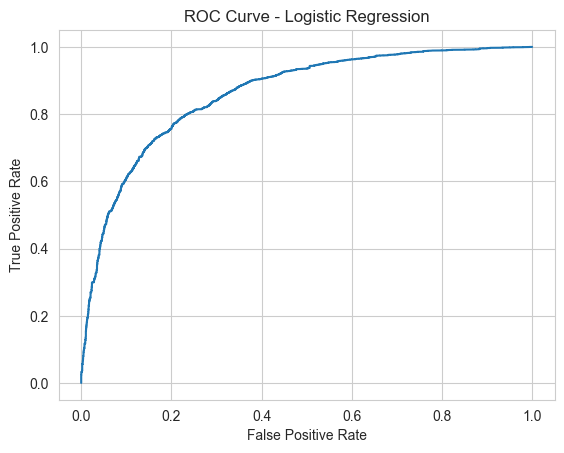

np.float64(0.6625548019194629)

In [94]:
from sklearn.metrics import roc_curve
import numpy as np
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.show()

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

optimal_threshold

In [95]:
y_pred_opt = (y_pred_prob > optimal_threshold).astype(int)

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print(confusion_matrix(y_test, y_pred_opt))
print(classification_report(y_test, y_pred_opt))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))

[[2770  796]
 [1532 5785]]
              precision    recall  f1-score   support

           0       0.64      0.78      0.70      3566
           1       0.88      0.79      0.83      7317

    accuracy                           0.79     10883
   macro avg       0.76      0.78      0.77     10883
weighted avg       0.80      0.79      0.79     10883

ROC-AUC: 0.860743839724806


Decision Tree Model

In [96]:
X_train_tree = X_train
X_test_tree = X_test

In [97]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_tree, y_train)

y_pred_dt = dt.predict(X_test_tree)
y_pred_dt_prob = dt.predict_proba(X_test_tree)[:, 1]

In [98]:
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_dt_prob))

[[2879  687]
 [ 682 6635]]
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      3566
           1       0.91      0.91      0.91      7317

    accuracy                           0.87     10883
   macro avg       0.86      0.86      0.86     10883
weighted avg       0.87      0.87      0.87     10883

ROC-AUC: 0.8602371983712358


Decision Tree Tuning (Pre-Pruning)

In [99]:
path = dt.cost_complexity_pruning_path(X_train_tree, y_train)
ccp_alphas = path.ccp_alphas

In [103]:
dt_models = []

for alpha in ccp_alphas:
    dt_temp = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    dt_temp.fit(X_train_tree, y_train)
    dt_models.append(dt_temp)

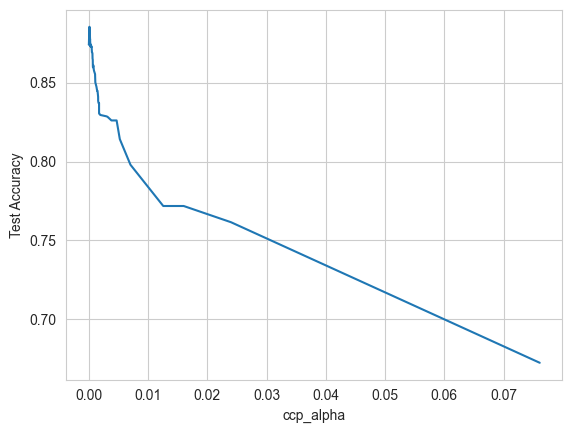

In [104]:
train_scores = []
test_scores = []

for model in dt_models:
    train_scores.append(model.score(X_train_tree, y_train))
    test_scores.append(model.score(X_test_tree, y_test))

plt.plot(ccp_alphas, test_scores)
plt.xlabel("ccp_alpha")
plt.ylabel("Test Accuracy")
plt.show()

In [105]:
dt_final = DecisionTreeClassifier(random_state=42, ccp_alpha=0.002)
dt_final.fit(X_train_tree, y_train)

y_pred_dt_final = dt_final.predict(X_test_tree)
y_pred_dt_final_prob = dt_final.predict_proba(X_test_tree)[:, 1]

print(confusion_matrix(y_test, y_pred_dt_final))
print(classification_report(y_test, y_pred_dt_final))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_dt_final_prob))

[[2389 1177]
 [ 677 6640]]
              precision    recall  f1-score   support

           0       0.78      0.67      0.72      3566
           1       0.85      0.91      0.88      7317

    accuracy                           0.83     10883
   macro avg       0.81      0.79      0.80     10883
weighted avg       0.83      0.83      0.83     10883

ROC-AUC: 0.8559947022166052


Model Comparison Table

In [106]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression (Tuned)",
        "Decision Tree (Base)",
        "Decision Tree (Pruned)"
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_pred_prob),
        roc_auc_score(y_test, y_pred_dt_prob),
        roc_auc_score(y_test, y_pred_dt_final_prob)
    ]
})

comparison

,Model,ROC_AUC
0,Logistic Regression (Tuned),0.860744
1,Decision Tree (Base),0.860237
2,Decision Tree (Pruned),0.855995
